In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
#rutas
SPLIT_PATH = "/content/drive/MyDrive/tesis/split_1.npz"

LABEL_ORDER = [1, 2, 3, 4, 5]
CLASS_NAMES = ["Hepatocito", "Estrellada", "Kupffer", "Endotelial", "Otras"]

RANDOM_STATE = 42

# Carpeta que guarda todo
OUTPUT_DIR = "/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# output
RESULTS_CSV_PATH      = os.path.join(OUTPUT_DIR, "mlp_hyperparameter_search_results.csv")
BEST_PARAMS_TXT_PATH  = os.path.join(OUTPUT_DIR, "best_params.txt")
FINAL_MODEL_PATH      = os.path.join(OUTPUT_DIR, "mlp_final_pipeline.pkl")

METRICS_CSV_PATH      = os.path.join(OUTPUT_DIR, "metrics_summary.csv")
METRICS_TXT_PATH      = os.path.join(OUTPUT_DIR, "metrics_report.txt")
METRICS_PNG_PATH      = os.path.join(OUTPUT_DIR, "metrics_summary.png")

CM_VAL_PATH           = os.path.join(OUTPUT_DIR, "confusion_matrix_validacion.png")
CM_TEST_PATH          = os.path.join(OUTPUT_DIR, "confusion_matrix_test.png")
LOSS_CURVE_PATH       = os.path.join(OUTPUT_DIR, "loss_curve_mlp.png")

print("Carpeta de salida:", OUTPUT_DIR)

Carpeta de salida: /content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1


In [ ]:
data = np.load(SPLIT_PATH)

X_train = data["X_train"]
y_train = data["y_train"]
X_val   = data["X_val"]
y_val   = data["y_val"]
X_test  = data["X_test"]
y_test  = data["y_test"]

print("Shapes:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "| y_test: ", y_test.shape)

print("\nClases únicas en train:", np.unique(y_train))
print("Clases únicas en val:  ", np.unique(y_val))
print("Clases únicas en test: ", np.unique(y_test))

def print_class_counts(y, split_name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\nConteo por clase - {split_name}")
    for u, c in zip(unique, counts):
        print(f"Clase {u}: {c}")

print_class_counts(y_train, "Train")
print_class_counts(y_val, "Validación")
print_class_counts(y_test, "Test")

Shapes:
X_train: (15750, 1024) | y_train: (15750,)
X_val:   (1750, 1024) | y_val:   (1750,)
X_test:  (3114, 1024) | y_test:  (3114,)

Clases únicas en train: [1 2 3 4 5]
Clases únicas en val:   [1 2 3 4 5]
Clases únicas en test:  [1 2 3 4 5]

Conteo por clase - Train
Clase 1: 3150
Clase 2: 3150
Clase 3: 3150
Clase 4: 3150
Clase 5: 3150

Conteo por clase - Validación
Clase 1: 350
Clase 2: 350
Clase 3: 350
Clase 4: 350
Clase 5: 350

Conteo por clase - Test
Clase 1: 1661
Clase 2: 215
Clase 3: 246
Clase 4: 978
Clase 5: 14


In [ ]:
# Funciones definidas
def evaluate_model(y_true, y_pred, split_name):
    acc = accuracy_score(y_true, y_pred)

    precision_w = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall_w    = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_w        = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    precision_m = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_m    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_m        = f1_score(y_true, y_pred, average="macro", zero_division=0)

    bal_acc     = balanced_accuracy_score(y_true, y_pred)

    report_txt = classification_report(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
        target_names=CLASS_NAMES,
        zero_division=0
    )

    print(f"\n{'='*60}")
    print(f"RESULTADOS - {split_name}")
    print(f"{'='*60}")
    print(f"Accuracy           : {acc:.4f}")
    print(f"Precision weighted : {precision_w:.4f}")
    print(f"Recall weighted    : {recall_w:.4f}")
    print(f"F1 weighted        : {f1_w:.4f}")
    print(f"Precision macro    : {precision_m:.4f}")
    print(f"Recall macro       : {recall_m:.4f}")
    print(f"F1 macro           : {f1_m:.4f}")
    print(f"Balanced Accuracy  : {bal_acc:.4f}")

    print("\nClassification Report:")
    print(report_txt)

    metrics_dict = {
        "split": split_name,
        "accuracy": acc,
        "precision_weighted": precision_w,
        "recall_weighted": recall_w,
        "f1_weighted": f1_w,
        "precision_macro": precision_m,
        "recall_macro": recall_m,
        "f1_macro": f1_m,
        "balanced_accuracy": bal_acc
    }

    return metrics_dict, report_txt


def save_confusion_matrix(y_true, y_pred, split_name, save_path):
    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES
    )
    disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45, colorbar=False)
    plt.title(f"Matriz de confusión - {split_name}")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Guardado: {save_path}")


def save_loss_curve(mlp_model, save_path):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(mlp_model.loss_curve_)
    ax.set_title("Curva de pérdida - MLP")
    ax.set_xlabel("Época / Iteración")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Guardado: {save_path}")


def save_metrics_table_png(metrics_df, save_path):
    df_show = metrics_df.copy().round(4)

    fig, ax = plt.subplots(figsize=(12, 2 + 0.5 * len(df_show)))
    ax.axis("off")

    table = ax.table(
        cellText=df_show.values,
        colLabels=df_show.columns,
        loc="center",
        cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    plt.title("Resumen de métricas", pad=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Guardado: {save_path}")


In [ ]:
param_grid = {
    "pca__n_components": [0.95, 256],
    "pca__whiten": [False],
    "mlp__hidden_layer_sizes": [
        (256,),
        (256, 128),
        (512, 256),
        (256, 128, 64)
    ],
    "mlp__alpha": [1e-4, 1e-3],
    "mlp__learning_rate_init": [1e-5, 1e-4, 1e-3],
    "mlp__batch_size": [128, 256],
}

all_combinations = list(product(
    param_grid["pca__n_components"],
    param_grid["pca__whiten"],
    param_grid["mlp__hidden_layer_sizes"],
    param_grid["mlp__alpha"],
    param_grid["mlp__learning_rate_init"],
    param_grid["mlp__batch_size"]
))

print(f"Total de combinaciones a probar: {len(all_combinations)}")

results = []
best_score = -1
best_params = None
best_model_search = None

for i, (n_components, whiten, hidden_layer_sizes, alpha, learning_rate_init, batch_size) in enumerate(all_combinations, start=1):
    print(f"\n[{i}/{len(all_combinations)}]")

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(
            n_components=n_components,
            whiten=whiten,
            random_state=RANDOM_STATE
        )),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation="relu",
            solver="adam",
            alpha=alpha,
            batch_size=batch_size,
            learning_rate_init=learning_rate_init,
            max_iter=400,
            shuffle=True,
            random_state=RANDOM_STATE,
            early_stopping=True,
            n_iter_no_change=15,
            verbose=False
        ))
    ])

    pipe.fit(X_train, y_train)
    y_val_pred = pipe.predict(X_val)

    acc_val = accuracy_score(y_val, y_val_pred)
    f1_w_val = f1_score(y_val, y_val_pred, average="weighted", zero_division=0)
    f1_m_val = f1_score(y_val, y_val_pred, average="macro", zero_division=0)
    bal_acc_val = balanced_accuracy_score(y_val, y_val_pred)

    results.append({
        "pca__n_components": n_components,
        "pca__whiten": whiten,
        "hidden_layer_sizes": str(hidden_layer_sizes),
        "alpha": alpha,
        "learning_rate_init": learning_rate_init,
        "batch_size": batch_size,
        "accuracy_val": acc_val,
        "f1_weighted_val": f1_w_val,
        "f1_macro_val": f1_m_val,
        "balanced_acc_val": bal_acc_val,
        "n_iter_": pipe.named_steps["mlp"].n_iter_,
    })

    print(f"Val Accuracy    : {acc_val:.4f}")
    print(f"Val F1 weighted : {f1_w_val:.4f}")
    print(f"Val F1 macro    : {f1_m_val:.4f}")
    print(f"Val Bal Accuracy: {bal_acc_val:.4f}")
    print(f"n_iter_         : {pipe.named_steps['mlp'].n_iter_}")

    if f1_m_val > best_score:
        best_score = f1_m_val
        best_params = {
            "pca__n_components": n_components,
            "pca__whiten": whiten,
            "hidden_layer_sizes": hidden_layer_sizes,
            "alpha": alpha,
            "learning_rate_init": learning_rate_init,
            "batch_size": batch_size
        }
        best_model_search = pipe

results_df = pd.DataFrame(results).sort_values("f1_macro_val", ascending=False).reset_index(drop=True)

print("\nBest params:")
print(best_params)

print("\nTop 10 resultados:")
print(results_df.head(10))

results_df.to_csv(RESULTS_CSV_PATH, index=False)
print(f"\nResultados guardados en: {RESULTS_CSV_PATH}")

Total de combinaciones a probar: 96

[1/96]
Val Accuracy    : 0.7469
Val F1 weighted : 0.7463
Val F1 macro    : 0.7463
Val Bal Accuracy: 0.7469
n_iter_         : 129

[2/96]
Val Accuracy    : 0.7429
Val F1 weighted : 0.7426
Val F1 macro    : 0.7426
Val Bal Accuracy: 0.7429
n_iter_         : 152

[3/96]
Val Accuracy    : 0.7886
Val F1 weighted : 0.7882
Val F1 macro    : 0.7882
Val Bal Accuracy: 0.7886
n_iter_         : 134

[4/96]
Val Accuracy    : 0.7817
Val F1 weighted : 0.7816
Val F1 macro    : 0.7816
Val Bal Accuracy: 0.7817
n_iter_         : 180

[5/96]
Val Accuracy    : 0.7851
Val F1 weighted : 0.7852
Val F1 macro    : 0.7852
Val Bal Accuracy: 0.7851
n_iter_         : 31

[6/96]
Val Accuracy    : 0.7891
Val F1 weighted : 0.7892
Val F1 macro    : 0.7892
Val Bal Accuracy: 0.7891
n_iter_         : 72

[7/96]
Val Accuracy    : 0.7469
Val F1 weighted : 0.7463
Val F1 macro    : 0.7463
Val Bal Accuracy: 0.7469
n_iter_         : 129

[8/96]
Val Accuracy    : 0.7429
Val F1 weighted : 0.742

In [ ]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(
        n_components=best_params["pca__n_components"],
        whiten=best_params["pca__whiten"],
        random_state=RANDOM_STATE
    )),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=best_params["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=best_params["alpha"],
        batch_size=best_params["batch_size"],
        learning_rate_init=best_params["learning_rate_init"],
        max_iter=250,
        shuffle=True,
        random_state=RANDOM_STATE,
        early_stopping=False,
        verbose=False
    ))
])

final_model.fit(X_train, y_train)

print("Modelo final entrenado correctamente con Scaler + PCA + MLP.")
print("Iteraciones usadas:", final_model.named_steps["mlp"].n_iter_)

y_train_pred = final_model.predict(X_train)
y_val_pred   = final_model.predict(X_val)
y_test_pred  = final_model.predict(X_test)

train_metrics, train_report = evaluate_model(y_train, y_train_pred, "Train")
val_metrics, val_report     = evaluate_model(y_val, y_val_pred, "Validación")
test_metrics, test_report   = evaluate_model(y_test, y_test_pred, "Test")

metrics_df = pd.DataFrame([train_metrics, val_metrics, test_metrics])

print("\nResumen de métricas:")
print(metrics_df.round(4))

Modelo final entrenado correctamente con Scaler + PCA + MLP.
Iteraciones usadas: 29

RESULTADOS - Train
Accuracy           : 1.0000
Precision weighted : 1.0000
Recall weighted    : 1.0000
F1 weighted        : 1.0000
Precision macro    : 1.0000
Recall macro       : 1.0000
F1 macro           : 1.0000
Balanced Accuracy  : 1.0000

Classification Report:
              precision    recall  f1-score   support

  Hepatocito       1.00      1.00      1.00      3150
  Estrellada       1.00      1.00      1.00      3150
     Kupffer       1.00      1.00      1.00      3150
  Endotelial       1.00      1.00      1.00      3150
       Otras       1.00      1.00      1.00      3150

    accuracy                           1.00     15750
   macro avg       1.00      1.00      1.00     15750
weighted avg       1.00      1.00      1.00     15750


RESULTADOS - Validación
Accuracy           : 0.8006
Precision weighted : 0.7996
Recall weighted    : 0.8006
F1 weighted        : 0.7991
Precision macro    : 0

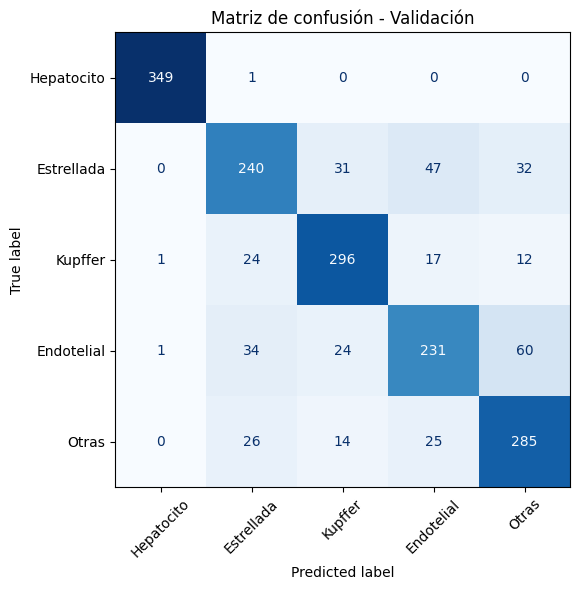

Guardado: /content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/confusion_matrix_validacion.png


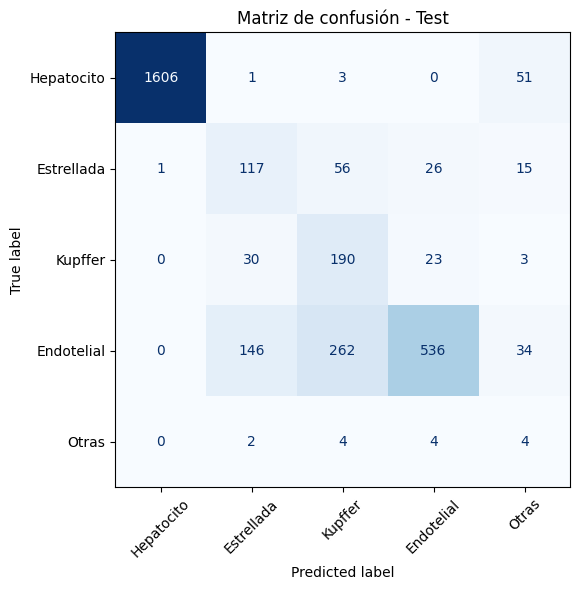

Guardado: /content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/confusion_matrix_test.png


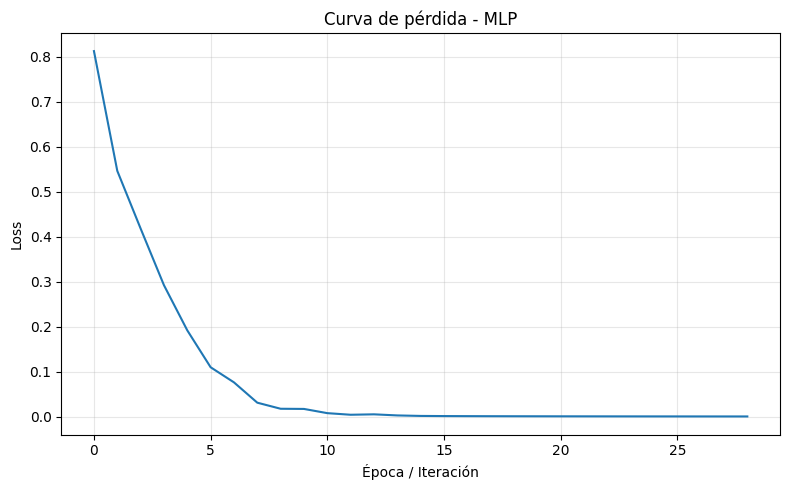

Guardado: /content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/loss_curve_mlp.png


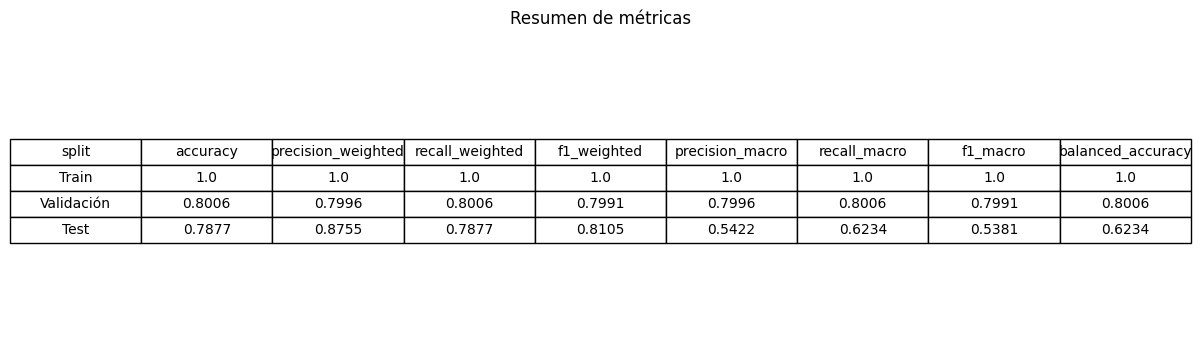

Guardado: /content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/metrics_summary.png

Archivos guardados correctamente:
/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/mlp_hyperparameter_search_results.csv
/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/best_params.txt
/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/mlp_final_pipeline.pkl
/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/metrics_summary.csv
/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/metrics_report.txt
/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/metrics_summary.png
/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/confusion_matrix_validacion.png
/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/confusion_matrix_test.png
/content/drive/MyDrive/tesis/mlp_pca_pipeline_run_1/loss_curve_mlp.png


In [ ]:
save_confusion_matrix(y_val, y_val_pred, "Validación", CM_VAL_PATH)
save_confusion_matrix(y_test, y_test_pred, "Test", CM_TEST_PATH)

save_loss_curve(final_model.named_steps["mlp"], LOSS_CURVE_PATH)

metrics_df.to_csv(METRICS_CSV_PATH, index=False)
save_metrics_table_png(metrics_df, METRICS_PNG_PATH)

with open(BEST_PARAMS_TXT_PATH, "w", encoding="utf-8") as f:
    f.write("MEJORES HIPERPARÁMETROS (selección por F1 macro en validación)\n")
    f.write("=" * 70 + "\n")
    for k, v in best_params.items():
        f.write(f"{k}: {v}\n")
    f.write(f"\nBest F1 macro (val): {best_score:.6f}\n")

with open(METRICS_TXT_PATH, "w", encoding="utf-8") as f:
    f.write("REPORTE COMPLETO - MLP + PCA + SCALER\n")
    f.write("=" * 80 + "\n\n")

    f.write("Shapes de entrada\n")
    f.write("-" * 80 + "\n")
    f.write(f"X_train: {X_train.shape} | y_train: {y_train.shape}\n")
    f.write(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}\n")
    f.write(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}\n\n")

    f.write("Mejores hiperparámetros\n")
    f.write("-" * 80 + "\n")
    for k, v in best_params.items():
        f.write(f"{k}: {v}\n")
    f.write(f"\nBest F1 macro (val): {best_score:.6f}\n\n")

    f.write("Resumen numérico de métricas\n")
    f.write("-" * 80 + "\n")
    f.write(metrics_df.to_string(index=False))
    f.write("\n\n")

    f.write("Classification Report - Train\n")
    f.write("-" * 80 + "\n")
    f.write(train_report)
    f.write("\n\n")

    f.write("Classification Report - Validación\n")
    f.write("-" * 80 + "\n")
    f.write(val_report)
    f.write("\n\n")

    f.write("Classification Report - Test\n")
    f.write("-" * 80 + "\n")
    f.write(test_report)
    f.write("\n\n")

joblib.dump(final_model, FINAL_MODEL_PATH)

print("\nArchivos guardados correctamente:")
print(RESULTS_CSV_PATH)
print(BEST_PARAMS_TXT_PATH)
print(FINAL_MODEL_PATH)
print(METRICS_CSV_PATH)
print(METRICS_TXT_PATH)
print(METRICS_PNG_PATH)
print(CM_VAL_PATH)
print(CM_TEST_PATH)
print(LOSS_CURVE_PATH)

In [ ]:
print("Mejores hiperparámetros finales:")
print(best_params)

print("\nTop 5 combinaciones por F1 macro:")
print(results_df.head(5))

Mejores hiperparámetros finales:
{'pca__n_components': 256, 'pca__whiten': False, 'hidden_layer_sizes': (512, 256), 'alpha': 0.0001, 'learning_rate_init': 0.001, 'batch_size': 128}

Top 5 combinaciones por F1 macro:
   pca__n_components  pca__whiten hidden_layer_sizes   alpha  \
0             256.00        False         (512, 256)  0.0001   
1             256.00        False         (512, 256)  0.0010   
2               0.95        False         (512, 256)  0.0010   
3               0.95        False         (512, 256)  0.0001   
4               0.95        False         (512, 256)  0.0001   

   learning_rate_init  batch_size  accuracy_val  f1_weighted_val  \
0               0.001         128      0.797143         0.796247   
1               0.001         128      0.794857         0.793962   
2               0.001         256      0.794286         0.793185   
3               0.001         256      0.793143         0.792304   
4               0.001         128      0.792571         0.7